# 01 — Preprocessing Exploration
Compare the pipeline behavior on **Amazon Fine Food Reviews** vs **Sentiment140**.

Key question: same code, same config → does behavior differ? Why?

In [11]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from preprocessor import TextPreprocessor
from preprocessor import PreprocessorConfig

## 1. Load Datasets

In [12]:
# Amazon Fine Food Reviews
amazon_df = pd.read_csv('../data/raw/Amazon Fine Food Reviews.csv')
amazon_df = amazon_df[['Text', 'Score']].dropna()
amazon_df['label'] = (amazon_df['Score'] >= 4).astype(int)  # 1=positive, 0=negative
print(f'Amazon: {len(amazon_df):,} rows')
amazon_df.head(3)

Amazon: 568,454 rows


,Text,Score,label
0,I have bought several of the Vitality canned d...,5,1
1,Product arrived labeled as Jumbo Salted Peanut...,1,0
2,This is a confection that has been around a fe...,4,1


In [13]:
twitter_df = pd.read_csv('../data/raw/Sentiment140.csv',
    encoding='latin-1',
    header=None,
    names=['polarity', 'id', 'date', 'query', 'user', 'text']
)
twitter_df['label'] = (twitter_df['polarity'] == 4).astype(int)
print(f'Twitter: {len(twitter_df):,} rows')
twitter_df[['text', 'label']].head(3)

Twitter: 1,600,000 rows


,text,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0


## 2. Instantiate Preprocessors (domain-specific configs)

In [14]:
amazon_p = TextPreprocessor(TextPreprocessor.amazon_config())
twitter_p = TextPreprocessor(TextPreprocessor.twitter_config())

## 3. Step-by-step breakdown (explain method)

In [15]:
sample_amazon = amazon_df['Text'].iloc[0]
print('=== AMAZON EXPLAIN ===')
for k, v in amazon_p.explain(sample_amazon).items():
    print(f'{k:25s}: {str(v)[:120]}')

=== AMAZON EXPLAIN ===
original                 : I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The produc
after_cleaning           : i have bought several of the vitality canned dog food products and have found them all to be of good quality the product
tokens_raw               : ['i', 'have', 'bought', 'several', 'of', 'the', 'vitality', 'canned', 'dog', 'food', 'products', 'and', 'have', 'found',
tokens_normalized        : ['bought', 'several', 'vitality', 'canned', 'dog', 'food', 'product', 'found', 'good', 'quality', 'product', 'look', 'li
final                    : bought several vitality canned dog food product found good quality product look like stew processed meat smell better la


In [16]:
sample_tweet = twitter_df['text'].iloc[0]
print('=== TWITTER EXPLAIN ===')
for k, v in twitter_p.explain(sample_tweet).items():
    print(f'{k:25s}: {str(v)[:120]}')

=== TWITTER EXPLAIN ===
original                 : @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D
after_cleaning           : awww that is a bummer you shoulda got david carr of third day to do it d
tokens_raw               : ['awww', 'that', 'is', 'a', 'bummer', 'you', 'shoulda', 'got', 'david', 'carr', 'of', 'third', 'day', 'to', 'do', 'it', 
tokens_normalized        : ['awww', 'bummer', 'shoulda', 'got', 'david', 'carr', 'third', 'day']
final                    : awww bummer shoulda got david carr third day


## 4. Process full datasets (sample for speed)

In [ ]:
amazon_sample = amazon_df
twitter_sample = twitter_df

amazon_sample['processed'] = amazon_p.process_batch(amazon_sample['Text'].tolist(), show_progress=True)
twitter_sample['processed'] = twitter_p.process_batch(twitter_sample['text'].tolist(), show_progress=True)

print('Done!')

Preprocessing: 100%|██████████| 568454/568454 [00:58<00:00, 9703.28it/s] 


Done!


## 5. Token length distribution — key insight!

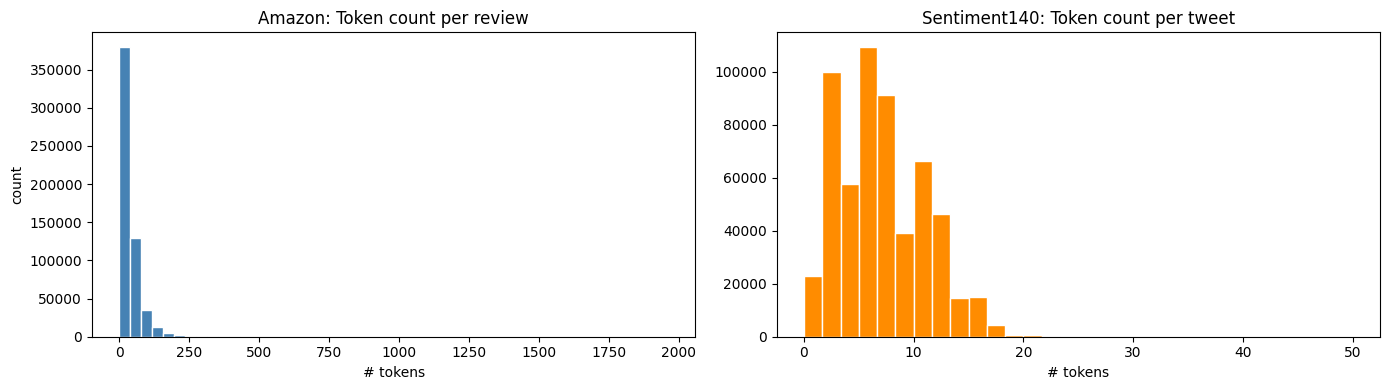

Amazon  — mean tokens: 39.9, median: 28.0
Twitter — mean tokens: 7.0, median: 6.0


In [18]:
amazon_lengths = amazon_sample['processed'].str.split().str.len()
twitter_lengths = twitter_sample['processed'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(amazon_lengths, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Amazon: Token count per review')
axes[0].set_xlabel('# tokens')
axes[0].set_ylabel('count')

axes[1].hist(twitter_lengths, bins=30, color='darkorange', edgecolor='white')
axes[1].set_title('Sentiment140: Token count per tweet')
axes[1].set_xlabel('# tokens')

plt.tight_layout()
plt.savefig('../reports/figures/token_length_distribution.png', dpi=150)
plt.show()

print(f'Amazon  — mean tokens: {amazon_lengths.mean():.1f}, median: {amazon_lengths.median()}')
print(f'Twitter — mean tokens: {twitter_lengths.mean():.1f}, median: {twitter_lengths.median()}')

## 6. Top-30 tokens per dataset
This reveals domain vocabulary differences — important for choosing stopwords.

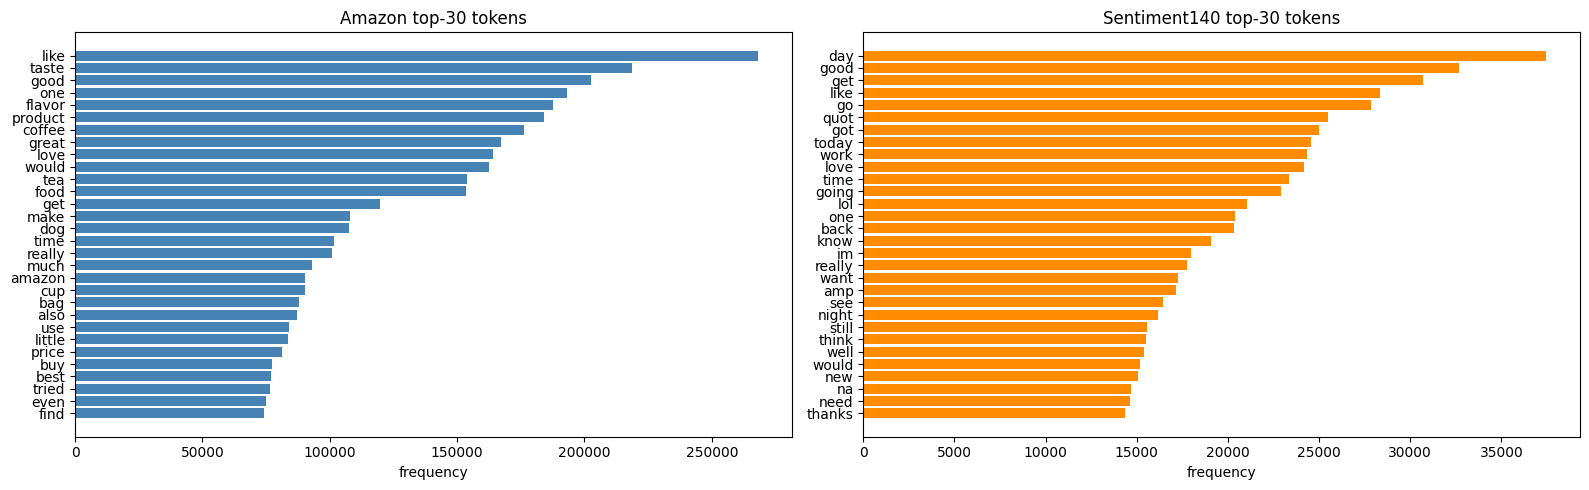

In [19]:
def top_tokens(series, n=30):
    all_tokens = ' '.join(series.dropna()).split()
    return Counter(all_tokens).most_common(n)

amazon_top  = top_tokens(amazon_sample['processed'])
twitter_top = top_tokens(twitter_sample['processed'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, data, title, color in [
    (axes[0], amazon_top,  'Amazon top-30 tokens',   'steelblue'),
    (axes[1], twitter_top, 'Sentiment140 top-30 tokens', 'darkorange'),
]:
    words, counts = zip(*data)
    ax.barh(words[::-1], counts[::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel('frequency')

plt.tight_layout()
plt.savefig('../reports/figures/top_tokens.png', dpi=150)
plt.show()

## 7. Save processed data
These files go under DVC tracking — NOT committed to git directly.

In [20]:
import os
os.makedirs('../data/processed', exist_ok=True)

amazon_sample[['processed', 'label']].to_csv('../data/processed/amazon_processed.csv', index=False)
twitter_sample[['processed', 'label']].to_csv('../data/processed/twitter_processed.csv', index=False)

print('Saved to data/processed/')
print('Run: dvc add data/processed/ && dvc push')

Saved to data/processed/
Run: dvc add data/processed/ && dvc push
